# Entrega 1 modelazación de variables categóricas — TSDS 2025/2026
## Motivación:

Elegir una carrera universitaria en España es, en muchos sentidos, una apuesta a ciegas. Los estudiantes toman una decisión que condiciona años de su vida con información muy parcial sobre lo que les espera al otro lado: ¿qué tipo de trabajo consiguen los que estudian lo mismo que yo? ¿importa si la universidad es pública o privada? ¿cambia algo ser hombre o mujer, venir de una familia con estudios o sin ellos?

La Encuesta de inserción laboral de titulados universitarios (EILU 2019) recoge la situación profesional de más de 37.000 estudiantes cuatro años después de terminar la carrera. Es una fotografía única de la realidad del mercado laboral universitario español, y usarla bien puede revelar patrones que ni las guías orientativas ni la intuición popular son capaces de detectar.

Nos interesa especialmente entender si la situación laboral de un estudiantes es predecible a partir de características que se conocen antes de empezar a trabajar: el tipo de estudios, el tipo de universidad, el origen socioeconómico familiar, la movilidad geográfica.

## Fase 1: Exploración de Datos (EDA) y Preprocesado
**Propuesta:** Optimización de captación para universidades privadas — Lead Scoring para predecir destino profesional según tipo de universidad.

**Variable objetivo:** `SIT_PRO`  4 segmentos multiclase:
- **0 --> Becario o sin empleo** (valores originales: vacío, 1)
- **1 --> Asalariado temporal** (valor original: 3)
- **2 --> Asalariado indefinido** (valor original: 2)
- **3 --> Autónomo o empresario** (valores originales: 4, 5, 6)

**Dataset:** EILU_GRAD_2019.csv
**Integrantes del grupo:** Fernando Marañón, Javier Marín, Juan Pérez, Álvaro Sánchez.

---

## 1. Importación de librerías

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.ticker as mticker
import seaborn as sns
import category_encoders as ce
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas correctamente')

Librerías importadas correctamente


In [2]:
# Configuración visual
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
PALETTE = ['#2196F3', '#FF9800', '#4CAF50', '#F44336']

---
## 2. Carga del dataset

In [3]:
DATA_PATH = '../data/raw/EILU_GRAD_2019.csv'
df_raw = pd.read_csv(DATA_PATH,sep='\t',encoding='latin-1',dtype=str, low_memory=False)

print(f' Las dimensiones del dataset son: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
df_raw.head(10)

 Las dimensiones del dataset son: 31,651 filas × 299 columnas


,IDENT,SEXO,EDAD,NACIO,NACIO1,NACIO2,PAIS_NACI,TITU,RAMA,AMBITO,...,ANHCUR4,DENCUR5,DURCUR5,RESCUR5,ANHCUR5,DENCUR6,DURCUR6,RESCUR6,ANHCUR6,FACTOR
0,1,1,1,1,,,1,011101,3,011,...,,,,,,,,,,9.894742
1,2,1,1,1,,,1,011101,3,011,...,,,,,,,,,,9.894742
2,3,1,1,1,,,1,011101,3,011,...,,,,,,,,,,10.965467
3,4,1,1,1,,,1,011101,3,011,...,,,,,,,,,,10.859689
4,5,1,1,1,,,1,011101,3,011,...,,,,,,,,,,10.859689
5,6,1,1,1,,,1,011101,3,011,...,,,,,,,,,,10.859689
6,7,1,1,1,,,1,011101,3,011,...,,,,,,,,,,9.218739
7,8,2,1,1,,,1,011101,3,011,...,,,,,,,,,,14.211924
8,9,2,1,1,,,1,011101,3,011,...,,,,,,,,,,14.211924
9,10,2,1,1,,,1,011101,3,011,...,,,,,,,,,,14.211924


In [5]:
# Normalización: eliminamos los espacios extras en el nombre de las columnas y en los valores.
df_raw.columns = df_raw.columns.str.strip().str.upper()

# Reemplazamos las celdas vacías por NaN
df_raw.replace(r'^\s*$', np.nan, regex=True, inplace=True)

print(f'Columnas disponibles:')
print(df_raw.columns[:299].tolist())

Columnas disponibles:
['IDENT', 'SEXO', 'EDAD', 'NACIO', 'NACIO1', 'NACIO2', 'PAIS_NACI', 'TITU', 'RAMA', 'AMBITO', 'T_UNIV', 'DISCA', 'PROXY', 'LUG_RES_PAIS', 'PAIS_NAC_PADRE', 'ESTUDIOS_PADRE', 'PAIS_NAC_MADRE', 'ESTUDIOS_MADRE', 'EST_B1', 'EST_B2_1', 'EST_B2_2', 'EST_B2_3', 'EST_B2_4', 'EST_B2_5', 'EST_M1', 'EST_M2', 'EST_M3', 'EST_M4', 'EST_MES', 'EST_B8', 'SAT1', 'SAT2', 'EST_B11_1', 'EST_B11_2', 'EST_B11_3', 'EST_B11_4', 'EST_B11_5', 'EST_B11_6', 'EST_B11_7', 'EST_B12', 'EST_B13_AMB1', 'EST_B14_1', 'EST_B15_1', 'EST_B13_AMB2', 'EST_B14_2', 'EST_B15_2', 'EST_B13_AMB3', 'EST_B14_3', 'EST_B15_3', 'EST_B16', 'EST_B17_M1', 'EST_B18_1', 'EST_B19_1', 'EST_B17_M2', 'EST_B18_2', 'EST_B19_2', 'EST_B17_M3', 'EST_B18_3', 'EST_B19_3', 'EST_B21', 'EST_B22', 'EST_B23', 'EST_B24', 'EST_B25_FA1', 'EST_B26_1', 'EST_B27_1', 'EST_B25_FA2', 'EST_B26_2', 'EST_B27_2', 'EST_B25_FA3', 'EST_B26_3', 'EST_B27_3', 'EST_B28', 'EST_B29_FA1', 'EST_B30_1', 'EST_B31_1', 'EST_B29_FA2', 'EST_B30_2', 'EST_B31_2', 'E

---
## 3. Variables
### 3.1 Selección de variables relevantes.

In [6]:
VAR_OBJETIVO  = ['SIT_PRO']

VAR_PREDICTORAS = [
    'T_UNIV',           # Tipo de universidad (pública/privada)
    'RAMA',             # Rama de conocimiento
    'ESTUDIOS_PADRE',   # Nivel de estudios del padre
    'ESTUDIOS_MADRE',   # Nivel de estudios de la madre
    'MOV_IN',           # Movilidad interprovincial
    'SEXO',             # Género del estudiante
    'EDAD',             # Tramo de edad al graduar
    'DISCA',            # Discapacidad reconocida
    'SAT1',             # Satisfacción con la formación recibida
    'SAT2',             # Satisfacción con la utilidad para el empleo
    'TIC',              # Nivel de competencias TIC autodeclarado
]

VAR_INTERES = VAR_OBJETIVO + VAR_PREDICTORAS

# Verificamos qué variables existen en el dataset
disponibles = [v for v in VAR_INTERES if v in df_raw.columns]
faltantes   = [v for v in VAR_INTERES if v not in df_raw.columns]

print(f'Variables encontradas ({len(disponibles)}): {disponibles}')

if faltantes:
    print(f'\n Variables NO encontradas: {faltantes}')
    print('\nLas columnas que realmente tiene tu dataset son:')
    print(list(df_raw.columns)[:50])


Variables encontradas (12): ['SIT_PRO', 'T_UNIV', 'RAMA', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE', 'MOV_IN', 'SEXO', 'EDAD', 'DISCA', 'SAT1', 'SAT2', 'TIC']


In [7]:
# Creamos un subconjunto de trabajo con las variables seleccionadas
df = df_raw[disponibles].copy()

print(f'Dataset de trabajo: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(15)

Dataset de trabajo: 31,651 filas × 12 columnas


,SIT_PRO,T_UNIV,RAMA,ESTUDIOS_PADRE,ESTUDIOS_MADRE,MOV_IN,SEXO,EDAD,DISCA,SAT1,SAT2,TIC
0,2,2,3,2,3,1,1,1,2,1,2,2
1,2,2,3,3,3,2,1,1,2,1,1,2
2,3,1,3,3,3,1,1,1,2,1,1,3
3,3,1,3,7,7,2,1,1,2,1,1,3
4,NaN,1,3,8,2,1,1,1,2,1,2,2
5,2,1,3,3,3,1,1,1,2,1,1,2
6,NaN,1,3,5,3,2,1,1,2,2,NaN,2
7,3,1,3,4,4,1,2,1,2,1,1,2
8,2,1,3,4,5,2,2,1,2,1,1,1
9,2,1,3,8,6,1,2,1,2,1,1,2


### 3.2 Variables seleccionadas: tipos, cardinalidad y valores nulos

In [8]:
def variables_seleccionadas(dataframe):
    rows = []
    for col in dataframe.columns:
        n_null   = dataframe[col].isna().sum()
        pct_null = n_null / len(dataframe) * 100
        n_uniq   = dataframe[col].nunique(dropna=True)
        vals     = sorted(dataframe[col].dropna().unique().tolist()) if n_uniq <= 12 else '(alta cardinalidad)'
        rows.append({
            'Variable': col,
            'Tipo': dataframe[col].dtype,
            'Cardinalidad': n_uniq,
            'Nulos (n)': n_null,
            'Nulos (%)': round(pct_null, 2),
            'Valores únicos': vals
        })
    return pd.DataFrame(rows).set_index('Variable')

inv = variables_seleccionadas(df)
inv

,Tipo,Cardinalidad,Nulos (n),Nulos (%),Valores únicos
Variable,,,,,
SIT_PRO,object,6,4527,14.30,"[1, 2, 3, 4, 5, 6]"
T_UNIV,object,4,0,0.00,"[1, 2, 3, 4]"
RAMA,object,5,0,0.00,"[1, 2, 3, 4, 5]"
ESTUDIOS_PADRE,object,9,0,0.00,"[1, 2, 3, 4, 5, 6, 7, 8, 9]"
ESTUDIOS_MADRE,object,9,0,0.00,"[1, 2, 3, 4, 5, 6, 7, 8, 9]"
MOV_IN,object,3,21,0.07,"[1, 2, 9]"
SEXO,object,2,0,0.00,"[1, 2]"
EDAD,object,3,0,0.00,"[1, 2, 3]"
DISCA,object,2,0,0.00,"[1, 2]"


### 3.3 Descripción de las variables

#### Variables del enunciado

| Variable | Descripción | Tipo estadístico | Valores |
|---|---|---|---|
| `SIT_PRO` | Situación profesional actual | Nominal (objetivo) | vacío=sin empleo, 1=becario, 2=indef., 3=temporal, 4=empresario, 5=autónomo, 6=familiar |
| `T_UNIV` | Tipo de universidad | Nominal | 1=pública presencial, 2=pública distancia, 3=privada presencial, 4=privada distancia |
| `RAMA` | Rama de conocimiento | Nominal | 1=Artes, 2=Ciencias, 3=Sociales, 4=Ingeniería, 5=Salud |
| `ESTUDIOS_PADRE` | Nivel formativo del padre | Ordinal (8 niv.) | 1=sin alfabetizar … 8=universitarios, 9=NS/NC |
| `ESTUDIOS_MADRE` | Nivel formativo de la madre | Ordinal (8 niv.) | 1=sin alfabetizar … 8=universitarios, 9=NS/NC |
| `MOV_IN` | Movilidad interprovincial | Binaria | 1=Sí, 2=No |
| `SEXO` | Sexo del egresado | Binaria | 1=Hombre, 2=Mujer |
| `EDAD` | Tramo de edad al graduar | Ordinal | 1=<25, 2=25-29, 3=30-34, 4=≥35 | Estudiantes mayores suelen haber compaginado estudios y trabajo, lo que condiciona directamente el tipo de inserción laboral y la clase objetivo. |
| `DISCA` | Discapacidad reconocida | Binaria | 1=Sí, 2=No | Variable de equidad. Los estudiantes con discapacidad acceden a cupos de empleo público y programas específicos, creando una distribución diferencial en las clases. Pequeña proporción pero efecto no trivial. |
| `SAT1` | Satisfacción con la formación recibida | Ordinal (1-4) | 1=Muy satisfecho … 4=Nada satisfecho | Indicador de calidad percibida del centro/titulación. Puede correlacionar con la reputación de la institución y actuar como proxy de señalización ante empleadores. |
| `SAT2` | Satisfacción con la utilidad para el empleo | Ordinal (1-4) | 1=Muy satisfecho … 4=Nada satisfecho | Más directamente ligada a la inserción que SAT1. Mide si el estudiante percibe que la carrera le preparó para trabajar. Alta correlación esperada con la clase objetivo. |
| `TIC` | Nivel de competencias TIC autodeclarado | Ordinal | 1=Básico, 2=Medio, 3=Avanzado | Capital humano complementario. Las competencias digitales son factor diferenciador para contratos indefinidos en sectores tecnológicos y de servicios. |




---
## 4. Variable objetivo

### Justificación del diseño de los 4 segmentos

La variable `SIT_PRO` original tiene 6 categorías + vacíos (sin empleo). Para la pregunta que vamos a respondes, reagrupamos en **4 segmentos**.

| Segmento | Código nuevo | Categorías originales | Razón |
|---|---|---|---|
| Becario o sin empleo | 0 | vacío, 1 | Peor resultado laboral |
| Contrato temporal | 1 | 3 | Empleo inestable |
| Contrato indefinido | 2 | 2 | Empleo estable |
| Autónomo o empresario | 3 | 4, 5, 6 | Perfil emprendedor |

In [9]:
# Mapeo del nuevo SIT_PRO original (4 segmentos).
sit_pro_map = {
    np.nan: 0,   # sin empleo → Becario/sin empleo
    '1':    0,   # becario   → Becario/sin empleo
    '3':    1,   # temporal  → Contrato temporal
    '2':    2,   # indefinido→ Contrato indefinido
    '4':    3,   # empresario→ Autónomo/empresario
    '5':    3,   # autónomo  → Autónomo/empresario
    '6':    3,   # familiar  → Autónomo/empresario
}

df['TARGET'] = df['SIT_PRO'].map(sit_pro_map)

# Etiquetas
label_map = {
    0: 'Becario/Sin empleo',
    1: 'Contrato temporal',
    2: 'Contrato indefinido',
    3: 'Autónomo/Empresario'
}
df['TARGET_LABEL'] = df['TARGET'].map(label_map)

# Verificar del mapeo
n_mapeados = df['TARGET'].notna().sum()
print(f'Registros con TARGET asignado: {n_mapeados:,} / {len(df):,} ({n_mapeados/len(df)*100:.1f}%)')
print(f'Valores originales no mapeados: {df[df["TARGET"].isna()]["SIT_PRO"].value_counts().to_dict()}')

Registros con TARGET asignado: 31,651 / 31,651 (100.0%)
Valores originales no mapeados: {}


Distribución de la variable objetivo
                         n     %
TARGET_LABEL                    
Becario/Sin empleo    6035  19.1
Contrato temporal     7572  23.9
Contrato indefinido  15558  49.2
Autónomo/Empresario   2486   7.9


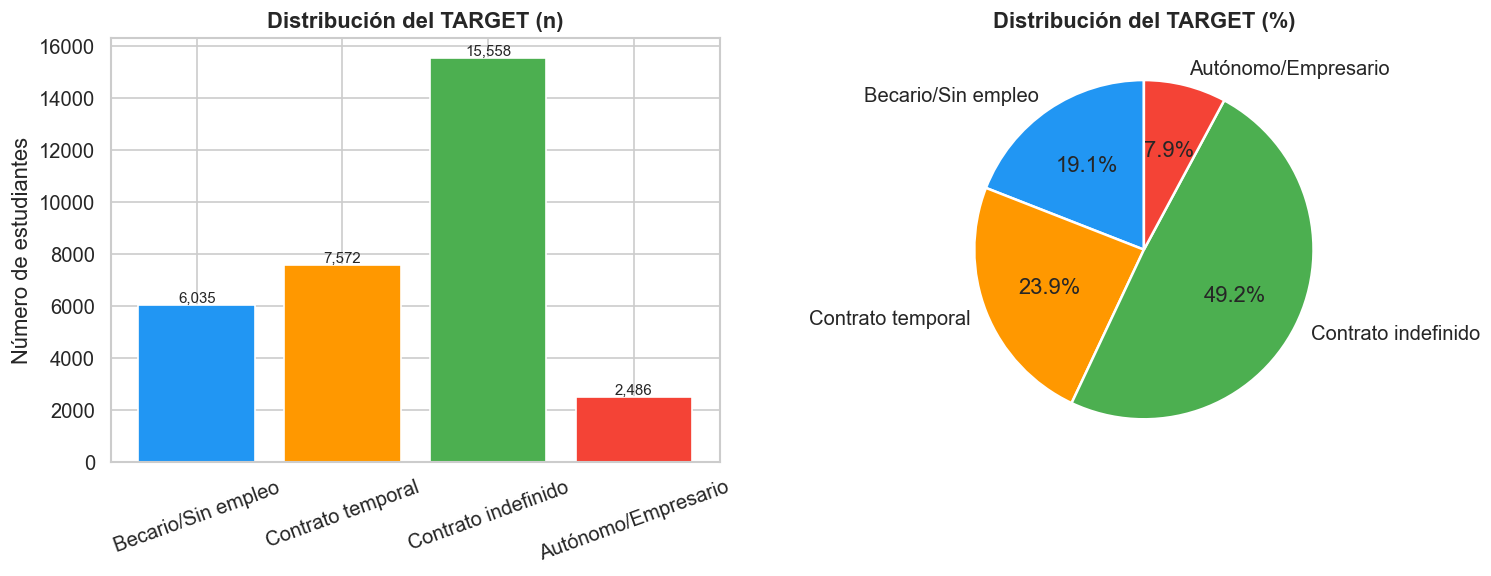

In [10]:
# Distribución del TARGET
dist_target = df['TARGET_LABEL'].value_counts().reindex(label_map.values())
dist_pct    = dist_target / dist_target.sum() * 100

print('Distribución de la variable objetivo')
resumen = pd.DataFrame({'n': dist_target, '%': dist_pct.round(1)})
print(resumen.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barplot
axes[0].bar(label_map.values(), dist_target.values, color=PALETTE, edgecolor='white')
axes[0].set_title('Distribución del TARGET (n)', fontweight='bold')
axes[0].set_ylabel('Número de estudiantes')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(dist_target.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

# Pie chart
axes[1].pie(dist_target.values, labels=label_map.values(),
            colors=PALETTE, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Distribución del TARGET (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/01_distribucion_target.png', bbox_inches='tight')
plt.show()

---
## 5. Identificación y tratamiento de valores faltantes

### 5.1 Valores nulos

Valores faltantes por variable predictora
                Nulos (n)  Nulos (%)
SAT2                 4497      14.21
MOV_IN                 21       0.07
T_UNIV                  0       0.00
ESTUDIOS_PADRE          0       0.00
RAMA                    0       0.00
SEXO                    0       0.00
ESTUDIOS_MADRE          0       0.00
EDAD                    0       0.00
DISCA                   0       0.00
SAT1                    0       0.00
TIC                     0       0.00


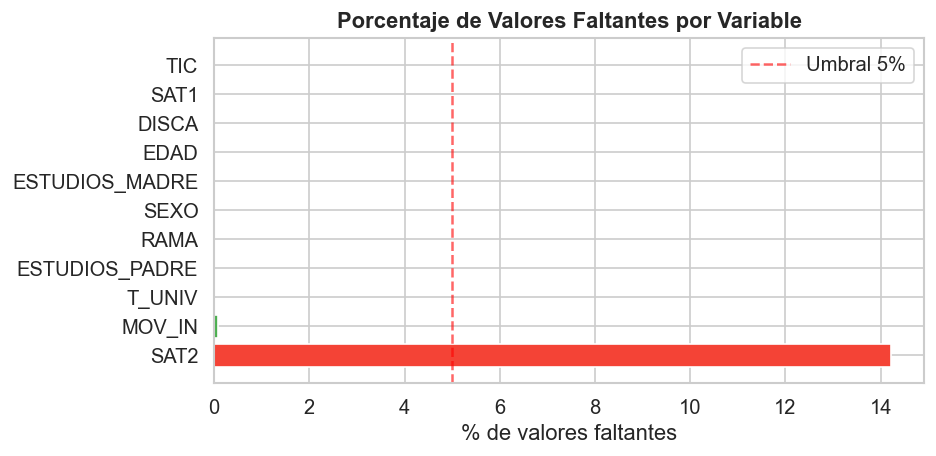

In [11]:
# Análisis de nulos por variable
nulos = df[VAR_PREDICTORAS].isna().sum().sort_values(ascending=False)
nulos_pct = (nulos / len(df) * 100).round(2)

df_nulos = pd.DataFrame({'Nulos (n)': nulos, 'Nulos (%)': nulos_pct})
print('Valores faltantes por variable predictora')
print(df_nulos.to_string())

# Visualización
fig, ax = plt.subplots(figsize=(8, 4))
colores = ['#F44336' if p > 5 else '#FF9800' if p > 1 else '#4CAF50' for p in nulos_pct]
ax.barh(nulos_pct.index, nulos_pct.values, color=colores, edgecolor='white')
ax.axvline(5, color='red', linestyle='--', alpha=0.6, label='Umbral 5%')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Porcentaje de Valores Faltantes por Variable', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/02_nulos_variables.png', bbox_inches='tight')
plt.show()

In [12]:
# Tratar ESTUDIOS_PADRE y ESTUDIOS_MADRE: valor 9 = NS/NC y convertimos en NaN
for col in ['ESTUDIOS_PADRE', 'ESTUDIOS_MADRE']:
    if col in df.columns:
        mask_9 = df[col] == '9'
        print(f'{col}: {mask_9.sum():,} valores «9» (NS/NC) convertidos a NaN')
        df.loc[mask_9, col] = np.nan

ESTUDIOS_PADRE: 2,200 valores «9» (NS/NC) convertidos a NaN
ESTUDIOS_MADRE: 1,467 valores «9» (NS/NC) convertidos a NaN


In [13]:
import os
os.makedirs('../outputs/figures', exist_ok=True)

df_clean = df.copy()

# 1. ESTUDIOS_PADRE y ESTUDIOS_MADRE: NaN por la categoría '9_NC'
for col in ['ESTUDIOS_PADRE', 'ESTUDIOS_MADRE']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('9_NC')

# 2. MOV_IN: NaN por la moda
if 'MOV_IN' in df_clean.columns:
    moda_mov = df_clean['MOV_IN'].mode()[0]
    df_clean['MOV_IN'] = df_clean['MOV_IN'].fillna(moda_mov)
    print(f'MOV_IN: imputado con moda = {moda_mov}')

# 3. Eliminamos las filas con nulos en variables nominales clave
n_antes = len(df_clean)
cols_drop_na = [c for c in ['T_UNIV', 'RAMA', 'SEXO'] if c in df_clean.columns]
df_clean = df_clean.dropna(subset=cols_drop_na + ['TARGET'])
n_despues = len(df_clean)
print(f'Filas eliminadas por nulos residuales: {n_antes - n_despues:,} ({(n_antes-n_despues)/n_antes*100:.2f}%)')
print(f'Dataset limpio final: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas')

MOV_IN: imputado con moda = 2
Filas eliminadas por nulos residuales: 0 (0.00%)
Dataset limpio final: 31,651 filas × 14 columnas


---
## 6. Análisis exploratorio (EDA)

### 6.1 Distribución de variables predictoras

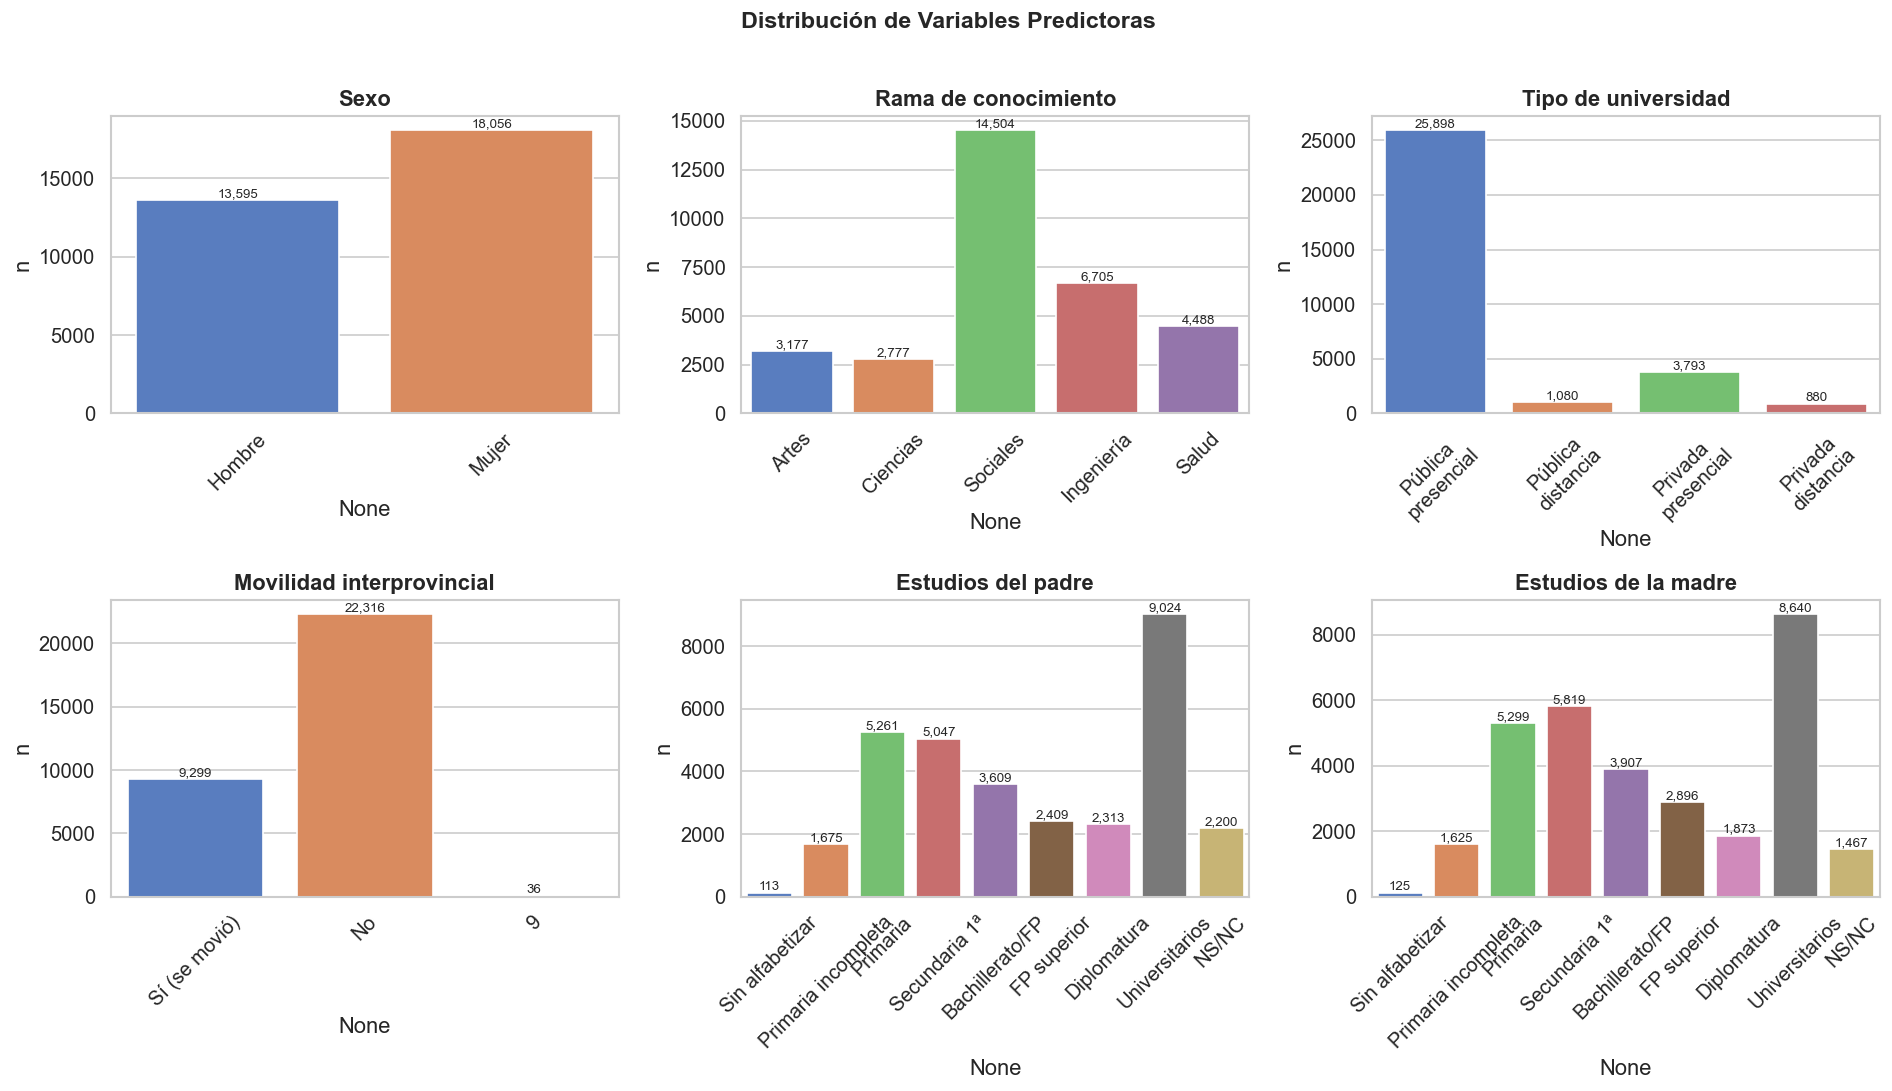

In [14]:
# Mapas de etiquetas para visualizaciones
etiquetas = {
    'SEXO':    {'1': 'Hombre', '2': 'Mujer'},
    'RAMA':    {'1': 'Artes', '2': 'Ciencias', '3': 'Sociales', '4': 'Ingeniería', '5': 'Salud'},
    'T_UNIV':  {'1': 'Pública\npresencial', '2': 'Pública\ndistancia',
                '3': 'Privada\npresencial', '4': 'Privada\ndistancia'},
    'MOV_IN':  {'1': 'Sí (se movió)', '2': 'No'},
    'ESTUDIOS_PADRE': {
        '1': 'Sin alfabetizar', '2': 'Primaria incompleta', '3': 'Primaria', 
        '4': 'Secundaria 1ª', '5': 'Bachillerato/FP', '6': 'FP superior',
        '7': 'Diplomatura', '8': 'Universitarios', '9_NC': 'NS/NC'
    },
    'ESTUDIOS_MADRE': {
        '1': 'Sin alfabetizar', '2': 'Primaria incompleta', '3': 'Primaria', 
        '4': 'Secundaria 1ª', '5': 'Bachillerato/FP', '6': 'FP superior',
        '7': 'Diplomatura', '8': 'Universitarios', '9_NC': 'NS/NC'
    }
}

def plot_distribucion(df, col, etiq_map=None, ax=None, title=None, palette='muted'):
    """Barplot de distribución para variable categórica."""
    counts = df[col].value_counts().sort_index()
    if etiq_map:
        counts.index = [etiq_map.get(str(k), str(k)) for k in counts.index]
    if ax is None:
        fig, ax = plt.subplots()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=palette, edgecolor='white')
    ax.set_title(title or col, fontweight='bold')
    ax.set_ylabel('n')
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)
    return ax

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

vars_plot = ['SEXO', 'RAMA', 'T_UNIV', 'MOV_IN', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE']
titulos   = ['Sexo', 'Rama de conocimiento', 'Tipo de universidad',
             'Movilidad interprovincial', 'Estudios del padre', 'Estudios de la madre']

for i, (col, tit) in enumerate(zip(vars_plot, titulos)):
    if col in df_clean.columns:
        plot_distribucion(df_clean, col, etiq_map=etiquetas.get(col), ax=axes[i], title=tit)

plt.suptitle('Distribución de Variables Predictoras', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/03_distribucion_variables.png', bbox_inches='tight')
plt.show()

### 6.2 Relación entre variables predictoras y TARGET

#### 6.2.1 Tipo de universidad (T_UNIV) vs TARGET 

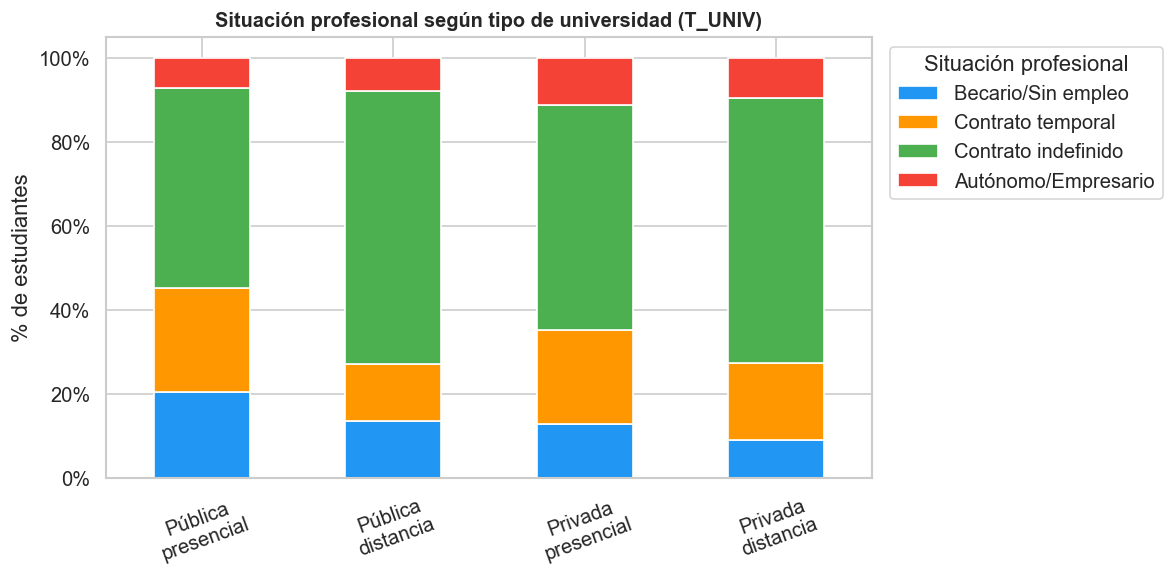


Tabla de porcentajes
TARGET_LABEL         Becario/Sin empleo  Contrato temporal  Contrato indefinido  Autónomo/Empresario
Pública\npresencial                20.5               24.8                 47.4                  7.3
Pública\ndistancia                 13.5               13.7                 64.8                  8.0
Privada\npresencial                13.0               22.3                 53.4                 11.3
Privada\ndistancia                  9.1               18.4                 62.8                  9.7


In [15]:
def plot_crosstab_pct(df, predictor, target_col='TARGET_LABEL', 
                      etiq_map=None, titulo='', palette=None):

    ct = pd.crosstab(df[predictor], df[target_col], normalize='index') * 100
    
    # Renombramos el índice por el mapa de etiquetas.
    if etiq_map:
        ct.index = [etiq_map.get(str(k), str(k)) for k in ct.index]
    
    # Reordenamos las columnas en orden lógico.
    cols_order = ['Becario/Sin empleo', 'Contrato temporal', 
                  'Contrato indefinido', 'Autónomo/Empresario']
    cols_order = [c for c in cols_order if c in ct.columns]
    ct = ct[cols_order]
    
    ax = ct.plot(kind='bar', stacked=True, 
                 color=PALETTE[:len(cols_order)],
                 edgecolor='white', figsize=(10, 5))
    ax.set_title(titulo, fontweight='bold', fontsize=12)
    ax.set_ylabel('% de estudiantes')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Situación profesional', bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    return ax, ct

ax, ct_tuniv = plot_crosstab_pct(
    df_clean, 'T_UNIV',
    etiq_map=etiquetas['T_UNIV'],
    titulo='Situación profesional según tipo de universidad (T_UNIV)'
)
plt.savefig('../outputs/figures/04_situacion_tuniv.png', bbox_inches='tight')
plt.show()

print('\nTabla de porcentajes')
print(ct_tuniv.round(1).to_string())

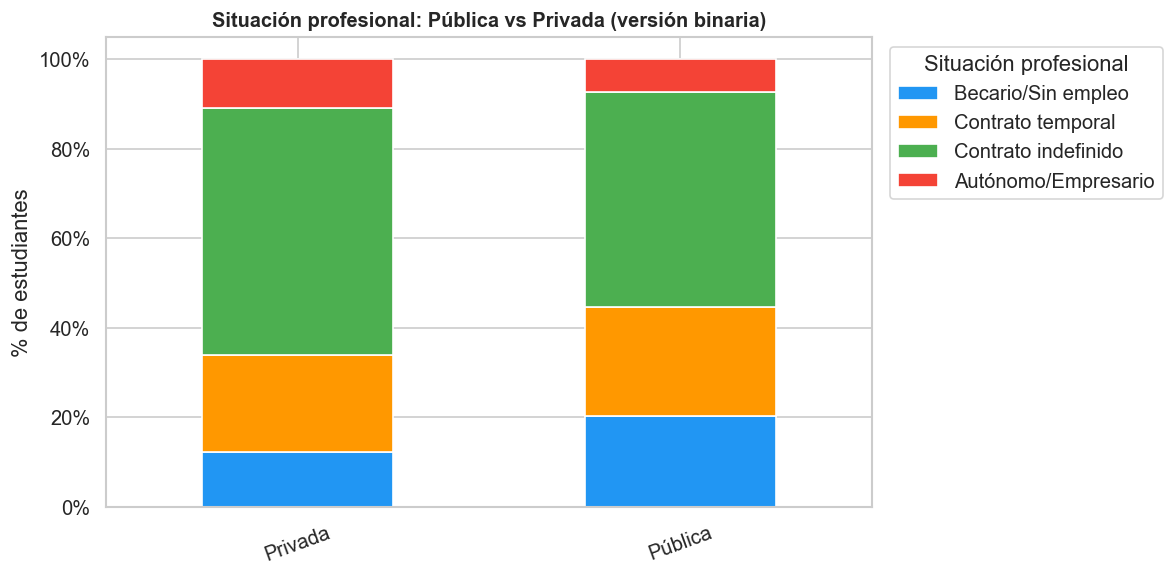

TARGET_LABEL  Becario/Sin empleo  Contrato temporal  Contrato indefinido  Autónomo/Empresario
T_UNIV_BIN                                                                                   
Privada                     12.3               21.6                 55.1                 11.0
Pública                     20.2               24.3                 48.1                  7.3


<Figure size 1200x600 with 0 Axes>

In [16]:
# Simplificación binaria de T_UNIV (pública vs privada) 
df_clean['T_UNIV_BIN'] = df_clean['T_UNIV'].map({
    '1': 'Pública', '2': 'Pública',
    '3': 'Privada', '4': 'Privada'
})

ax, ct_tuniv_bin = plot_crosstab_pct(
    df_clean, 'T_UNIV_BIN',
    titulo='Situación profesional: Pública vs Privada (versión binaria)'
)
plt.show()
plt.savefig('../outputs/figures/05_situacion_tuniv_bin.png', bbox_inches='tight')
print(ct_tuniv_bin.round(1).to_string())

#### 6.2.2 Rama de conocimiento (RAMA) vs TARGET

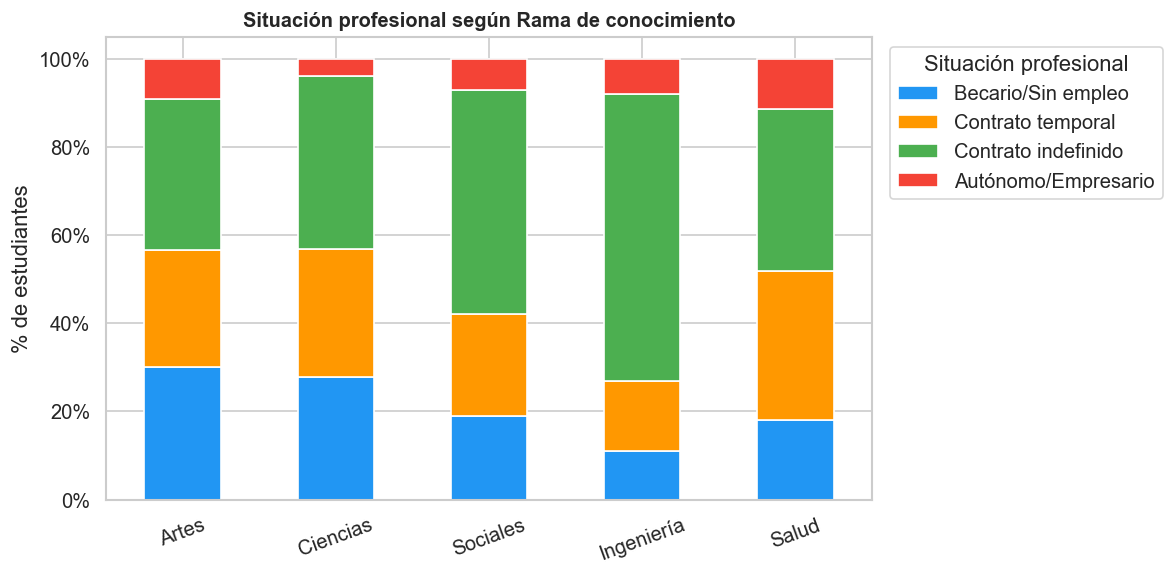

TARGET_LABEL  Becario/Sin empleo  Contrato temporal  Contrato indefinido  Autónomo/Empresario
Artes                       30.0               26.5                 34.3                  9.2
Ciencias                    27.7               29.0                 39.4                  3.9
Sociales                    19.1               23.0                 50.8                  7.2
Ingeniería                  11.0               15.9                 65.2                  7.9
Salud                       18.0               33.9                 36.6                 11.5


<Figure size 1200x600 with 0 Axes>

In [17]:
ax, ct_rama = plot_crosstab_pct(
    df_clean, 'RAMA',
    etiq_map=etiquetas['RAMA'],
    titulo='Situación profesional según Rama de conocimiento'
)
plt.show()
plt.savefig('../outputs/figures/06_situacion_rama_conocimiento.png', bbox_inches='tight')
print(ct_rama.round(1).to_string())

#### 6.2.3 Sexo vs TARGET

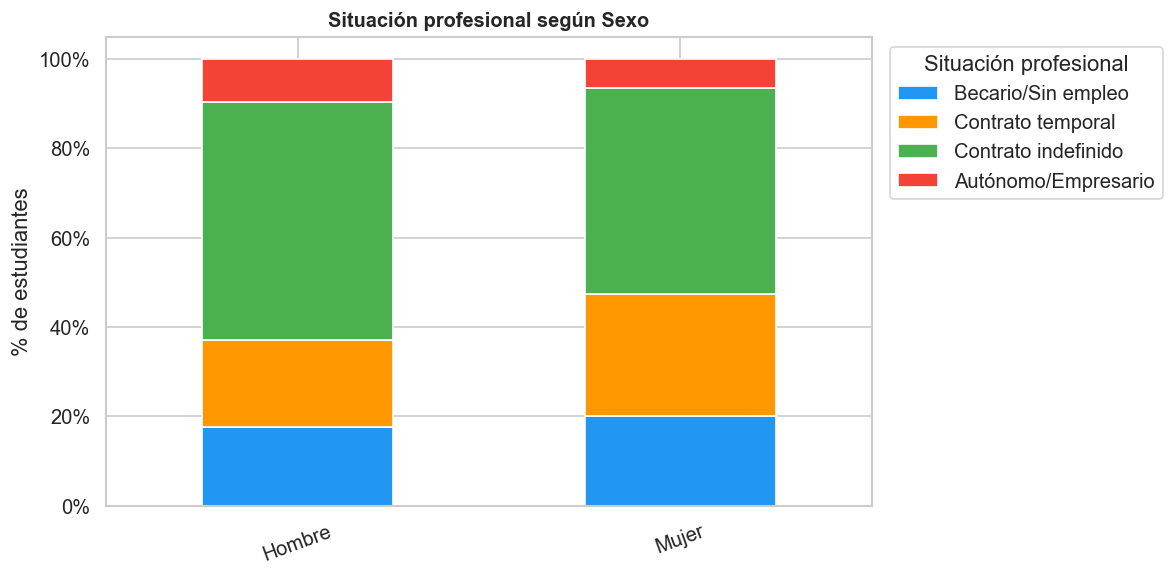

TARGET_LABEL  Becario/Sin empleo  Contrato temporal  Contrato indefinido  Autónomo/Empresario
Hombre                      17.7               19.5                 53.2                  9.7
Mujer                       20.1               27.3                 46.1                  6.5


<Figure size 1200x600 with 0 Axes>

In [18]:
ax, ct_sexo = plot_crosstab_pct(
    df_clean, 'SEXO',
    etiq_map=etiquetas['SEXO'],
    titulo='Situación profesional según Sexo'
)
plt.show()
plt.savefig('../outputs/figures/07_situacion_sexo.png', bbox_inches='tight')
print(ct_sexo.round(1).to_string())

#### 6.2.4 Movilidad interprovincial (MOV_IN) vs TARGET

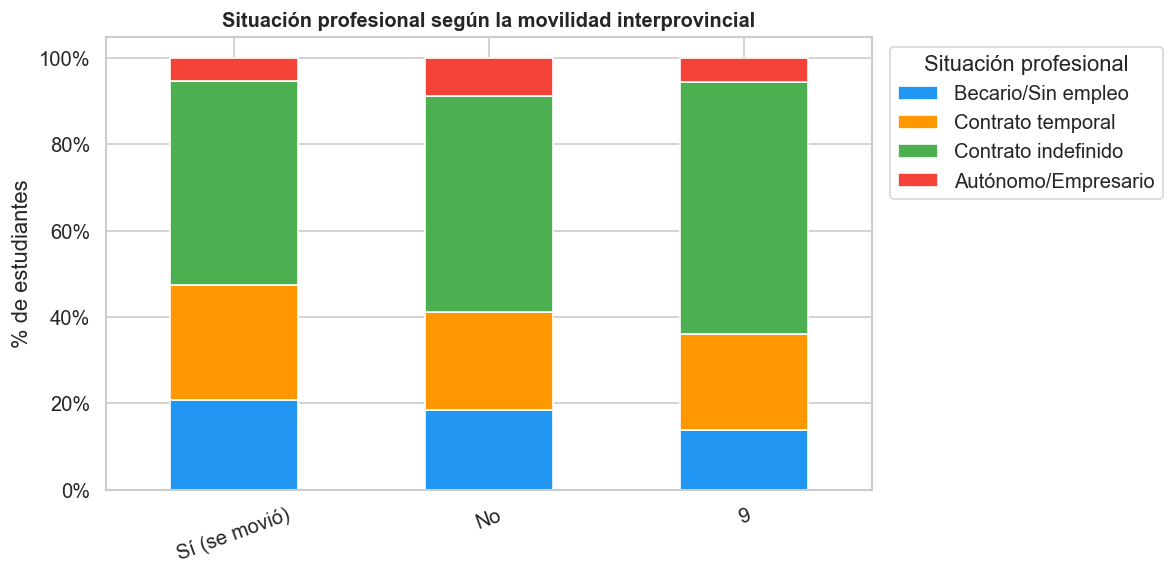

TARGET_LABEL   Becario/Sin empleo  Contrato temporal  Contrato indefinido  Autónomo/Empresario
Sí (se movió)                20.7               26.7                 47.2                  5.4
No                           18.4               22.8                 50.0                  8.9
9                            13.9               22.2                 58.3                  5.6


<Figure size 1200x600 with 0 Axes>

In [19]:
ax, ct_mov = plot_crosstab_pct(
    df_clean, 'MOV_IN',
    etiq_map=etiquetas['MOV_IN'],
    titulo='Situación profesional según la movilidad interprovincial'
)
plt.show()
plt.savefig('../outputs/figures/08_situacion_mov_in.png', bbox_inches='tight')
print(ct_mov.round(1).to_string())

#### 6.2.5 ESTUDIOS_PADRE / ESTUDIOS_MADRE vs TARGET

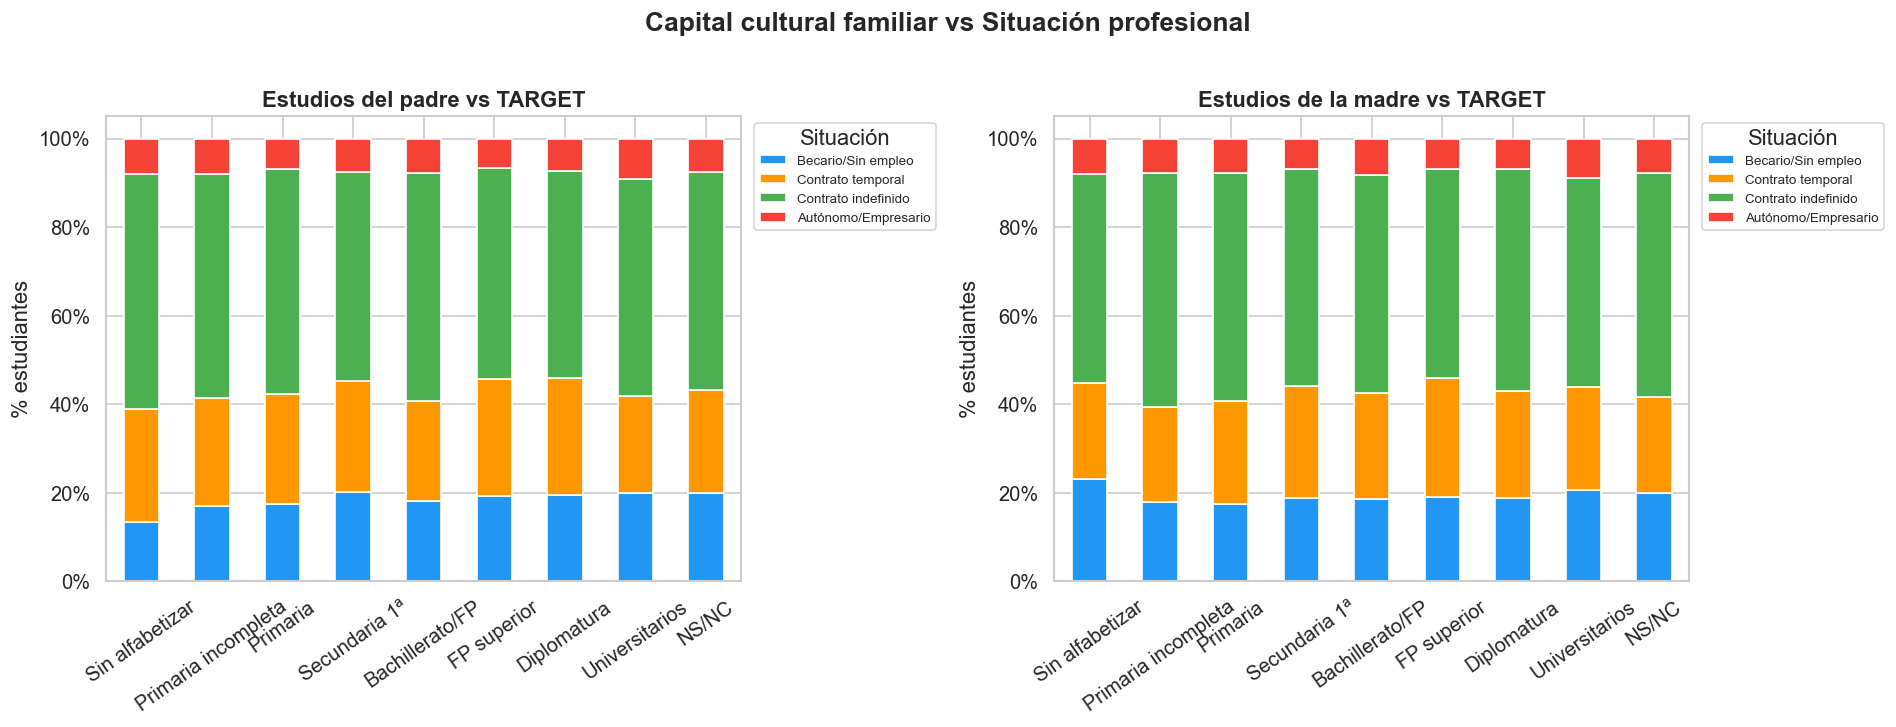

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (col, tit) in enumerate([('ESTUDIOS_PADRE', 'Estudios del padre vs TARGET'),
                                  ('ESTUDIOS_MADRE', 'Estudios de la madre vs TARGET')]):
    if col in df_clean.columns:
        ct = pd.crosstab(df_clean[col], df_clean['TARGET_LABEL'], normalize='index') * 100
        etiq = etiquetas[col]
        ct.index = [etiq.get(str(k), str(k)) for k in ct.index]
        cols_order = ['Becario/Sin empleo', 'Contrato temporal', 
                      'Contrato indefinido', 'Autónomo/Empresario']
        cols_order = [c for c in cols_order if c in ct.columns]
        ct[cols_order].plot(kind='bar', stacked=True, ax=axes[i],
                             color=PALETTE, edgecolor='white')
        axes[i].set_title(tit, fontweight='bold')
        axes[i].set_ylabel('% estudiantes')
        axes[i].tick_params(axis='x', rotation=35)
        axes[i].yaxis.set_major_formatter(mticker.PercentFormatter())
        axes[i].legend(title='Situación', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle('Capital cultural familiar vs Situación profesional', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/9_capital_cultural_familiar_vs_situacion_profesional.png', bbox_inches='tight')
plt.show()

---
## 7. Tablas de contingencia, Chi-cuadrado y V de Cramér

In [21]:
def cramers_v(contingency_table):
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    k = min(contingency_table.shape) - 1
    
    if k == 0 or n == 0:
        return chi2, p, dof, 0.0
        
    v = np.sqrt(chi2 / (n * k))
    return chi2, p, dof, v

def tabla_contingencia_analisis(df, predictor, target='TARGET', 
                                predictor_label=None, etiq_map=None, label_map=None):

    ct = pd.crosstab(df[predictor], df[target])
    chi2, p, dof, v = cramers_v(ct)
    
    label = predictor_label or predictor
    
    #  Imprimir las líneas sin error de comillas
    print('=' * 60)
    print(f'VARIABLE: {label}')
    print('=' * 60)
    
    # Tabla con etiquetas
    ct_display = ct.copy()
    if etiq_map:
        ct_display.index = [etiq_map.get(str(k), str(k)) for k in ct_display.index]
        
    # Añadida validación por si label_map no se proporciona
    if label_map:
        ct_display.columns = [label_map.get(c, str(c)) for c in ct_display.columns]
        
    print('\nTabla de contingencia (frecuencias absolutas):')
    print(ct_display.to_string())
    
    print(f'\nEstadístico χ²: {chi2:.2f}')
    print(f'p-valor:        {p:.6f} {"***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "(ns)"}')
    print(f'Grados de libertad: {dof}')
    print(f'V de Cramér:    {v:.4f}  →  ', end='')
    if v < 0.1:   print('Asociación muy débil')
    elif v < 0.2: print('Asociación débil')
    elif v < 0.3: print('Asociación moderada')
    else:         print('Asociación fuerte')
    
    return chi2, p, v

print('Función definida')

Función definida


In [22]:
# Análisis chi-cuadrado y V de Cramér para cada variable predictora
resultados_chi2 = []

vars_analisis = [
    ('T_UNIV',         'Tipo de universidad',         etiquetas['T_UNIV']),
    ('T_UNIV_BIN',     'Tipo universidad (binaria)',  None),
    ('RAMA',           'Rama de conocimiento',        etiquetas['RAMA']),
    ('SEXO',           'Sexo',                        etiquetas['SEXO']),
    ('MOV_IN',         'Movilidad interprovincial',   etiquetas['MOV_IN']),
    ('ESTUDIOS_PADRE', 'Estudios del padre',          etiquetas['ESTUDIOS_PADRE']),
    ('ESTUDIOS_MADRE', 'Estudios de la madre',        etiquetas['ESTUDIOS_MADRE']),
    ('EDAD',           'Edad al graduar',            None),
    ('DISCA',          'Discapacidad reconocida',    None),
    ('SAT1',           'Satisfacción con formación', None),
    ('SAT2',           'Satisfacción utilidad empleo', None),
    ('TIC',            'Competencias TIC',           None),
]

for col, label, etiqs in vars_analisis:
    if col in df_clean.columns:
        chi2_val, p_val, v_val = tabla_contingencia_analisis(
            df_clean, col, predictor_label=label, etiq_map=etiqs
        )
        resultados_chi2.append({'Variable': label, 'chi2': round(chi2_val,2),
                                 'p-valor': p_val, 'V Cramér': round(v_val,4)})
        print()

VARIABLE: Tipo de universidad

Tabla de contingencia (frecuencias absolutas):
TARGET                  0     1      2     3
Pública\npresencial  5316  6416  12281  1885
Pública\ndistancia    146   148    700    86
Privada\npresencial   493   846   2024   430
Privada\ndistancia     80   162    553    85

Estadístico χ²: 425.99
p-valor:        0.000000 ***
Grados de libertad: 9
V de Cramér:    0.0670  →  Asociación muy débil

VARIABLE: Tipo universidad (binaria)

Tabla de contingencia (frecuencias absolutas):
TARGET         0     1      2     3
T_UNIV_BIN                         
Privada      573  1008   2577   515
Pública     5462  6564  12981  1971

Estadístico χ²: 255.87
p-valor:        0.000000 ***
Grados de libertad: 3
V de Cramér:    0.0899  →  Asociación muy débil

VARIABLE: Rama de conocimiento

Tabla de contingencia (frecuencias absolutas):
TARGET         0     1     2     3
Artes        954   841  1091   291
Ciencias     769   806  1095   107
Sociales    2764  3340  7361  1039
I


RESUMEN: Fuerza de asociación con TARGET (V de Cramér)
                    Variable    chi2       p-valor  V Cramér
        Rama de conocimiento 1797.91  0.000000e+00    0.1376
                        Sexo  403.23  4.425806e-87    0.1129
             Edad al graduar  696.57 3.358284e-147    0.1049
  Tipo universidad (binaria)  255.87  3.513477e-55    0.0899
            Competencias TIC  505.39 4.034396e-103    0.0730
         Tipo de universidad  425.99  3.882496e-86    0.0670
  Satisfacción con formación  191.50  1.222016e-38    0.0550
   Movilidad interprovincial  174.92  4.064916e-35    0.0526
Satisfacción utilidad empleo   67.43  1.372470e-12    0.0352
     Discapacidad reconocida   37.60  3.431667e-08    0.0345
          Estudios del padre  100.27  2.706305e-11    0.0325
        Estudios de la madre   91.86  7.072373e-10    0.0311


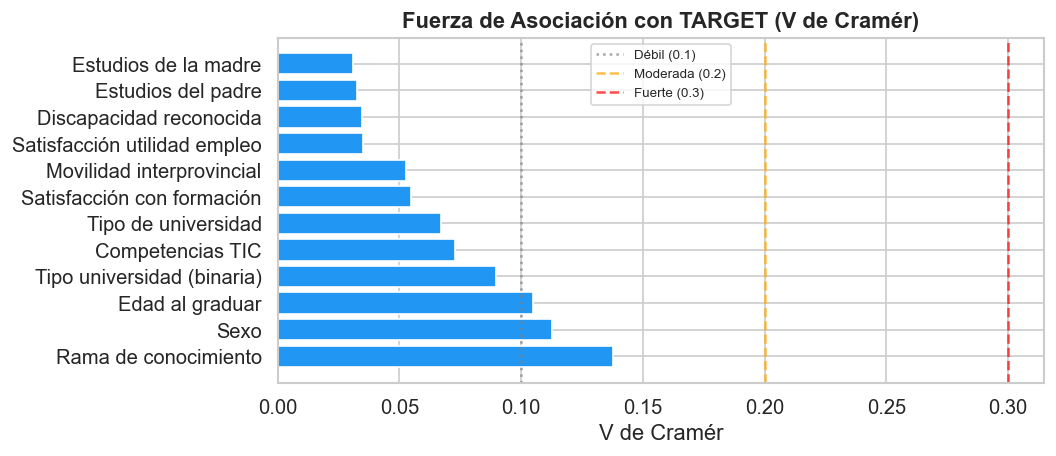

In [23]:
# Tabla resumen ordenada por V de Cramér
df_chi2_resumen = pd.DataFrame(resultados_chi2).sort_values('V Cramér', ascending=False)
print('\nRESUMEN: Fuerza de asociación con TARGET (V de Cramér)')
print(df_chi2_resumen.to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(9, 4))
colores_v = ['#F44336' if v >= 0.3 else '#FF9800' if v >= 0.2 else '#2196F3' 
             for v in df_chi2_resumen['V Cramér']]
ax.barh(df_chi2_resumen['Variable'], df_chi2_resumen['V Cramér'],
        color=colores_v, edgecolor='white')
ax.axvline(0.1, color='gray', linestyle=':', alpha=0.7, label='Débil (0.1)')
ax.axvline(0.2, color='orange', linestyle='--', alpha=0.7, label='Moderada (0.2)')
ax.axvline(0.3, color='red', linestyle='--', alpha=0.7, label='Fuerte (0.3)')
ax.set_xlabel('V de Cramér')
ax.set_title('Fuerza de Asociación con TARGET (V de Cramér)', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/figures/10_chi2_resumen.png', bbox_inches='tight')
plt.show()

---
## 8. Encoding de variables

### Justificación por variable

| Variable | Técnica | Justificación |
|---|---|---|
| `T_UNIV` | **One-Hot Encoding** | Nominal, 4 categorías. Sin orden implícito. Se convierte también en binaria (pública/privada)
| `RAMA` | **One-Hot Encoding** | Nominal, 5 categorías sin orden. No existe jerarquía entre ellas |
| `SEXO` | **Binary Encoding** (0/1) | Binaria; 1→0 (Hombre), 2→1 (Mujer) |
| `MOV_IN` | **Binary Encoding** (0/1) | Binaria; 1→1 (Sí), 2→0 (No) |
| `ESTUDIOS_PADRE` | **Ordinal Encoding** | Variable ordinal con orden natural (nivel educativo creciente). La categoría 9_NC se trata como categoría adicional al final |
| `ESTUDIOS_MADRE` | **Ordinal Encoding** | Variable ordinal con orden natural (nivel educativo creciente). La categoría 9_NC se trata como categoría adicional al final  |

In [24]:
df_encoded = df_clean.copy()

# 1. SEXO: Binary (1=Hombre→0, 2=Mujer→1) 
if 'SEXO' in df_encoded.columns:
    df_encoded['SEXO_enc'] = df_encoded['SEXO'].map({'1': 0, '2': 1}).astype('Int64')
    print('SEXO encoded: 1→0 (Hombre), 2→1 (Mujer)')

# 2. MOV_IN: Binary (1=Sí→1, 2=No→0) 
if 'MOV_IN' in df_encoded.columns:
    df_encoded['MOV_IN_enc'] = df_encoded['MOV_IN'].map({'1': 1, '2': 0}).astype('Int64')
    print('MOV_IN encoded: 1→1 (Sí), 2→0 (No)')

# 3. T_UNIV: One-Hot Encoding 
if 'T_UNIV' in df_encoded.columns:
    tuniv_dummies = pd.get_dummies(df_encoded['T_UNIV'], prefix='TUNIV', drop_first=False)
    tuniv_dummies.columns = [
        c.replace('TUNIV_1', 'TUNIV_pub_presencial')
         .replace('TUNIV_2', 'TUNIV_pub_distancia')
         .replace('TUNIV_3', 'TUNIV_priv_presencial')
         .replace('TUNIV_4', 'TUNIV_priv_distancia')
        for c in tuniv_dummies.columns
    ]
    df_encoded = pd.concat([df_encoded, tuniv_dummies], axis=1)
    
    if 'T_UNIV_BIN' in df_encoded.columns:
        df_encoded['TUNIV_privada'] = df_encoded['T_UNIV_BIN'].map({'Privada': 1, 'Pública': 0}).astype('Int64')
    
    print(f'T_UNIV one-hot → columnas: {list(tuniv_dummies.columns)}')

# 4. RAMA: One-Hot Encoding 
if 'RAMA' in df_encoded.columns:
    rama_dummies = pd.get_dummies(df_encoded['RAMA'], prefix='RAMA', drop_first=False)
    rama_dummies.columns = [
        c.replace('RAMA_1', 'RAMA_artes')
         .replace('RAMA_2', 'RAMA_ciencias')
         .replace('RAMA_3', 'RAMA_sociales')
         .replace('RAMA_4', 'RAMA_ingenieria')
         .replace('RAMA_5', 'RAMA_salud')
        for c in rama_dummies.columns
    ]
    df_encoded = pd.concat([df_encoded, rama_dummies], axis=1)
    print(f'RAMA one-hot → columnas: {list(rama_dummies.columns)}')
# 5. ESTUDIOS_PADRE y ESTUDIOS_MADRE: Ordinal Encoding
# Orden: sin alfabetizar (1) → universitarios (8) → NS/NC al final (9_NC=9)
orden_estudios = ['1', '2', '3', '4', '5', '6', '7', '8', '9_NC']
orden_num      = { v: i for i, v in enumerate(orden_estudios) }  # 0..8

for col in ['ESTUDIOS_PADRE', 'ESTUDIOS_MADRE']:
    if col in df_encoded.columns:
        df_encoded[f'{col}_enc'] = df_encoded[col].map(orden_num)
        n_null = df_encoded[f'{col}_enc'].isna().sum()
        print(f'{col}_enc → {orden_num} | NaN residuales: {n_null}')

print('\n Encoding completado')

SEXO encoded: 1→0 (Hombre), 2→1 (Mujer)
MOV_IN encoded: 1→1 (Sí), 2→0 (No)
T_UNIV one-hot → columnas: ['TUNIV_pub_presencial', 'TUNIV_pub_distancia', 'TUNIV_priv_presencial', 'TUNIV_priv_distancia']
RAMA one-hot → columnas: ['RAMA_artes', 'RAMA_ciencias', 'RAMA_sociales', 'RAMA_ingenieria', 'RAMA_salud']
ESTUDIOS_PADRE_enc → {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9_NC': 8} | NaN residuales: 0
ESTUDIOS_MADRE_enc → {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9_NC': 8} | NaN residuales: 0

 Encoding completado


In [25]:
# Resumen de columnas
cols_modelo = (
    ['SEXO_enc', 'MOV_IN_enc', 'TUNIV_privada',
     'TUNIV_pub_presencial', 'TUNIV_pub_distancia',
     'TUNIV_priv_presencial', 'TUNIV_priv_distancia',
     'RAMA_artes', 'RAMA_ciencias', 'RAMA_sociales',
     'RAMA_ingenieria', 'RAMA_salud',
     'ESTUDIOS_PADRE_enc', 'ESTUDIOS_MADRE_enc']
)
cols_disponibles = [c for c in cols_modelo if c in df_encoded.columns]

print(f'Features para modelos ({len(cols_disponibles)}): {cols_disponibles}')
print(f'Target: TARGET (0-3)')

# Vista previa del dataset final
df_encoded[cols_disponibles + ['TARGET']].head(15)

Features para modelos (14): ['SEXO_enc', 'MOV_IN_enc', 'TUNIV_privada', 'TUNIV_pub_presencial', 'TUNIV_pub_distancia', 'TUNIV_priv_presencial', 'TUNIV_priv_distancia', 'RAMA_artes', 'RAMA_ciencias', 'RAMA_sociales', 'RAMA_ingenieria', 'RAMA_salud', 'ESTUDIOS_PADRE_enc', 'ESTUDIOS_MADRE_enc']
Target: TARGET (0-3)


,SEXO_enc,MOV_IN_enc,TUNIV_privada,TUNIV_pub_presencial,TUNIV_pub_distancia,TUNIV_priv_presencial,TUNIV_priv_distancia,RAMA_artes,RAMA_ciencias,RAMA_sociales,RAMA_ingenieria,RAMA_salud,ESTUDIOS_PADRE_enc,ESTUDIOS_MADRE_enc,TARGET
0,0,1,0,False,True,False,False,False,False,True,False,False,1,2,2
1,0,0,0,False,True,False,False,False,False,True,False,False,2,2,2
2,0,1,0,True,False,False,False,False,False,True,False,False,2,2,1
3,0,0,0,True,False,False,False,False,False,True,False,False,6,6,1
4,0,1,0,True,False,False,False,False,False,True,False,False,7,1,0
5,0,1,0,True,False,False,False,False,False,True,False,False,2,2,2
6,0,0,0,True,False,False,False,False,False,True,False,False,4,2,0
7,1,1,0,True,False,False,False,False,False,True,False,False,3,3,1
8,1,0,0,True,False,False,False,False,False,True,False,False,3,4,2
9,1,1,0,True,False,False,False,False,False,True,False,False,7,5,2


In [26]:
import os

output_dir = '../data/clean'
os.makedirs(output_dir, exist_ok=True)

df_encoded.to_csv(f'{output_dir}/EILU_GRAD_processed.csv', index=False)

print(f'Dataset procesado guardado en {output_dir}/EILU_GRAD_processed.csv')
print(f'Shape final: {df_encoded.shape}')

Dataset procesado guardado en ../data/clean/EILU_GRAD_processed.csv
Shape final: (31651, 29)


---
## 9. Conclusiones del EDA


El análisis exploratorio del dataset EILU_GRAD_2019 revela varias conclusiones clave para nuestro objetivo que prediga el destino profesional de los estudiantes de grado en función de su perfil socioeducativo:

**1. Desbalanceo estructural de T_UNIV:** aproximadamente el 80% de los estudiantes procede de universidades públicas presenciales.

**2. La rama de conocimiento es el predictor más potente** (mayor V de Cramér con TARGET). La distribución de empleo difiere enormemente entre ramas: las carrereas de salud e ingeniería presentan las mayores tasas de empleo indefinido; artes y ciencias las menores. 

**3. El tipo de universidad muestra asociación moderada con el destino profesional**, pero es necesario controlar por RAMA para evitar confusión.

**4. Los estudios del padre y la madre tiene asociación significativa**.

**5. La movilidad interprovincial está asociada con mejores resultados laborales**, aunque la causalidad es difícil de establecer: quienes se mueven pueden ser perfiles más proactivos o con mayor capital social, independientemente de la movilidad en sí.

---
## 10. Propuesta de variable objetivo y justificación

### Variable objetivo: TARGET (multiclase, 4 categorías)

**Variable de partida:** `SIT_PRO` — Situación profesional actual del estudiante (7 valores posibles: vacío + 1 a 6).

**Transformación aplicada:** reagrupación en 4 segmentos interpretables:

**Tipo de modelo:** Clasificación multiclase nominal (no ordinal, porque los 4 segmentos no tienen un orden lineal, ya que un autónomo no es «más» que un trabajador con un contrato indefinido).

**Métrica principal:** AUC-ROC macro-averaged (robusta al desbalanceo). Complementaria: F1-macro.

In [27]:
# Vista final del target
print('Distribución final de la variable objetivo ')
dist_final = df_clean['TARGET'].value_counts().sort_index()
for k, v in dist_final.items():
    print(f'  [{k}] {label_map[k]:<25}: {v:>6,} ({v/len(df_clean)*100:.1f}%)')

print(f'\nTotal registros en dataset limpio: {len(df_clean):,}')

Distribución final de la variable objetivo 
  [0] Becario/Sin empleo       :  6,035 (19.1%)
  [1] Contrato temporal        :  7,572 (23.9%)
  [2] Contrato indefinido      : 15,558 (49.2%)
  [3] Autónomo/Empresario      :  2,486 (7.9%)

Total registros en dataset limpio: 31,651



## 11. Justificación de la elección del dataset (Grado)

Hemos elegido el dataset de **Grado** (EILU_GRAD_2019) por las siguientes razones:

1. **Mayor volumen** (32.000 registros vs 12.000 del máster): garantiza mayor potencia estadística para los modelos de clasificación multiclase, especialmente en las clases minoritarias.

2. **Adecuación a la pregunta de investigación:** la pregunta seleccionada sobre captación para universidades privadas tiene mayor sentido en el nivel de grado, donde la competencia pública/privada es más intensa y el mercado de captación más amplio.

3. **Variabilidad en T_UNIV:** aunque sigue siendo mayoritariamente pública, el dataset de Grado tiene mayor representación relativa de privadas que el de Máster, donde los másteres privados de alto precio distorsionan el análisis.

4. **Disponibilidad de variables relevantes:** las 299 variables del dataset de grado incluyen todas las predictoras de la pregunta seleccionada con cobertura suficiente.